# Understanding Chunking

How you split documents into chunks fundamentally shapes retrieval quality. This notebook explores three chunking strategies — **fixed**, **recursive**, and **sentence** — across the configurations from Experiment 1.

**What we'll cover:**
1. A sample document to chunk
2. Fixed chunking at three sizes (256, 512, 1024) with proportional overlap
3. Recursive chunking that respects paragraph/sentence boundaries
4. Sentence chunking that never splits mid-sentence
5. Visual comparison of chunk size distributions
6. Overlap verification

In [1]:
import sys
sys.path.insert(0, "..")

from src.ingest.chunkers import chunk_text, fixed_chunker, recursive_chunker, sentence_chunker

## 1. Sample Document

We'll use a multi-paragraph document with varied sentence lengths to see how each strategy handles natural text structure.

In [2]:
SAMPLE_DOC = """Retrieval-Augmented Generation (RAG) is a technique that combines the strengths of large language models with external knowledge retrieval. Instead of relying solely on the model's parametric memory, RAG systems fetch relevant documents from a knowledge base and include them in the prompt context. This approach reduces hallucination and allows the model to reference up-to-date or domain-specific information.

The first step in building a RAG system is document ingestion. Raw documents — PDFs, web pages, markdown files — must be parsed into plain text. This text is then split into smaller pieces called chunks. The quality of chunking directly affects retrieval: chunks that are too large dilute the signal with irrelevant context, while chunks that are too small lose coherence and miss important relationships between ideas.

Fixed-size chunking is the simplest strategy. It splits text into windows of N characters with an optional overlap between consecutive chunks. The overlap ensures that information near chunk boundaries isn't lost. However, fixed chunking ignores document structure entirely. A chunk boundary might fall in the middle of a sentence, a paragraph, or even a word.

Recursive chunking addresses this problem by trying to split at natural boundaries. It first attempts to split on paragraph breaks. If a paragraph is still too large, it splits on sentence boundaries. If a sentence is too long, it falls back to word boundaries, and finally to character-level splitting. This hierarchy preserves semantic coherence at the cost of slightly variable chunk sizes.

Sentence-based chunking takes a different approach. It identifies sentence boundaries using punctuation patterns and packs complete sentences into chunks up to a maximum size. A sentence is never split across chunks. This guarantees that every chunk contains grammatically complete units of meaning, which can improve both retrieval precision and the quality of generated answers.

Choosing the right chunk size involves trade-offs. Smaller chunks (128-256 characters) give precise retrieval but may lack context. Medium chunks (512-1024 characters) balance precision with context. Larger chunks (1024-2048 characters) preserve more context but may include irrelevant information that confuses the retriever. The optimal size depends on the embedding model, the retrieval method, and the nature of the queries.

Overlap between chunks serves as a safety net. When a relevant passage spans a chunk boundary, the overlapping region ensures that at least one chunk contains the complete passage. Typical overlap values range from 10% to 25% of the chunk size. Too much overlap wastes storage and computation; too little risks losing boundary information.

In practice, most production RAG systems use recursive chunking with chunk sizes between 256 and 1024 characters. The recursive approach provides a good balance between respecting document structure and maintaining consistent chunk sizes. However, the best strategy always depends on the specific use case, and systematic experimentation is essential to finding the optimal configuration."""

print(f"Document length: {len(SAMPLE_DOC):,} characters")
print(f"Paragraphs: {SAMPLE_DOC.count(chr(10) + chr(10)) + 1}")
print(f"Sentences (approx): {SAMPLE_DOC.count('. ') + SAMPLE_DOC.count('.')}")
print()
print("First 200 characters:")
print(SAMPLE_DOC[:200] + "...")

Document length: 3,132 characters
Paragraphs: 8
Sentences (approx): 58

First 200 characters:
Retrieval-Augmented Generation (RAG) is a technique that combines the strengths of large language models with external knowledge retrieval. Instead of relying solely on the model's parametric memory, ...


## 2. Fixed Chunking — Experiment 1a/1b/1c

Three configurations from the experiment plan:
- **1a:** chunk_size=256, overlap=25
- **1b:** chunk_size=512, overlap=50
- **1c:** chunk_size=1024, overlap=100

In [3]:
text = SAMPLE_DOC.strip()

fixed_configs = [
    ("1a: size=256, overlap=25", 256, 25),
    ("1b: size=512, overlap=50", 512, 50),
    ("1c: size=1024, overlap=100", 1024, 100),
]

fixed_results = {}
for label, size, overlap in fixed_configs:
    chunks = fixed_chunker(text, chunk_size=size, chunk_overlap=overlap)
    fixed_results[label] = chunks
    sizes = [len(c.text) for c in chunks]
    print(f"{label}")
    print(f"  Chunks: {len(chunks)}")
    print(f"  Sizes:  min={min(sizes)}, max={max(sizes)}, avg={sum(sizes)/len(sizes):.0f}")
    print()

1a: size=256, overlap=25
  Chunks: 14
  Sizes:  min=129, max=256, avg=247

1b: size=512, overlap=50
  Chunks: 7
  Sizes:  min=360, max=512, avg=490

1c: size=1024, overlap=100
  Chunks: 4
  Sizes:  min=360, max=1024, avg=858



### Inspecting fixed chunk boundaries

Notice how fixed chunking cuts through sentences and words without regard for meaning:

In [4]:
# Show where fixed chunking (1a) cuts through text
chunks_1a = fixed_results["1a: size=256, overlap=25"]
for i, chunk in enumerate(chunks_1a[:4]):
    end_preview = chunk.text[-40:].replace("\n", "\\n")
    print(f"Chunk {i} ends with: ...{end_preview!r}")
    if i < len(chunks_1a) - 1:
        start_preview = chunks_1a[i + 1].text[:40].replace("\n", "\\n")
        print(f"Chunk {i+1} starts with: {start_preview!r}...")
        print(f"  Overlap: {chunk.text[-25:]!r}")
        print()

Chunk 0 ends with: ...'h relevant documents from a knowledge ba'
Chunk 1 starts with: 'ments from a knowledge base and include '...
  Overlap: 'ments from a knowledge ba'

Chunk 1 ends with: ...'ystem is document ingestion. Raw documen'
Chunk 2 starts with: 'nt ingestion. Raw documents — PDFs, web '...
  Overlap: 'nt ingestion. Raw documen'

Chunk 2 ends with: ...'at are too large dilute the signal with '
Chunk 3 starts with: 'e dilute the signal with irrelevant cont'...
  Overlap: 'e dilute the signal with '

Chunk 3 ends with: ...'f N characters with an optional overlap '
Chunk 4 starts with: 'with an optional overlap between consecu'...
  Overlap: 'with an optional overlap '



## 3. Recursive Chunking — Experiment 1d

Recursive chunking respects document structure by splitting at paragraph breaks first, then sentences, then words.

In [5]:
recursive_chunks = recursive_chunker(text, chunk_size=512, chunk_overlap=50)
sizes = [len(c.text) for c in recursive_chunks]

print(f"Recursive (size=512, overlap=50)")
print(f"  Chunks: {len(recursive_chunks)}")
print(f"  Sizes:  min={min(sizes)}, max={max(sizes)}, avg={sum(sizes)/len(sizes):.0f}")
print()

for i, chunk in enumerate(recursive_chunks):
    # Show first line of each chunk to see how it splits at natural boundaries
    first_line = chunk.text[:80].replace("\n", "\\n")
    print(f"  Chunk {i} ({len(chunk.text):>3} chars): {first_line!r}...")

Recursive (size=512, overlap=50)
  Chunks: 8
  Sizes:  min=391, max=480, avg=435

  Chunk 0 (413 chars): 'Retrieval-Augmented Generation (RAG) is a technique that combines the strengths '...
  Chunk 1 (471 chars): 'rence up-to-date or domain-specific information.\\n\\nThe first step in building a R'...
  Chunk 2 (412 chars): ' and miss important relationships between ideas.\\n\\nFixed-size chunking is the sim'...
  Chunk 3 (445 chars): 'ddle of a sentence, a paragraph, or even a word.\\n\\nRecursive chunking addresses t'...
  Chunk 4 (432 chars): 'ce at the cost of slightly variable chunk sizes.\\n\\nSentence-based chunking takes '...
  Chunk 5 (480 chars): ' precision and the quality of generated answers.\\n\\nChoosing the right chunk size '...
  Chunk 6 (391 chars): 'retrieval method, and the nature of the queries.\\n\\nOverlap between chunks serves '...
  Chunk 7 (438 chars): 'n; too little risks losing boundary information.\\n\\nIn practice, most production R'...


### Recursive vs Fixed: boundary quality

Compare what happens at chunk boundaries. Recursive chunking splits at paragraph or sentence boundaries, while fixed chunking cuts mid-word:

In [6]:
fixed_512 = fixed_results["1b: size=512, overlap=50"]

print("=== Fixed (512) chunk boundaries ===")
for i in range(min(3, len(fixed_512) - 1)):
    end = fixed_512[i].text[-50:].replace("\n", "\\n")
    print(f"  Chunk {i} ends:   ...{end!r}")

print()
print("=== Recursive (512) chunk boundaries ===")
for i in range(min(3, len(recursive_chunks) - 1)):
    end = recursive_chunks[i].text[-50:].replace("\n", "\\n")
    print(f"  Chunk {i} ends:   ...{end!r}")

=== Fixed (512) chunk boundaries ===
  Chunk 0 ends:   ...'nt ingestion. Raw documents — PDFs, web pages, mar'
  Chunk 1 ends:   ...'with an optional overlap between consecutive chunk'
  Chunk 2 ends:   ...'oundaries. If a sentence is too long, it falls bac'

=== Recursive (512) chunk boundaries ===
  Chunk 0 ends:   ...'rence up-to-date or domain-specific information.\\n\\n'
  Chunk 1 ends:   ...' and miss important relationships between ideas.\\n\\n'
  Chunk 2 ends:   ...'ddle of a sentence, a paragraph, or even a word.\\n\\n'


## 4. Sentence Chunking

Sentence chunking never splits mid-sentence. It packs complete sentences into chunks up to the size limit.

In [7]:
sentence_chunks = sentence_chunker(text, chunk_size=512, chunk_overlap=50)
sizes = [len(c.text) for c in sentence_chunks]

print(f"Sentence (size=512, overlap=50)")
print(f"  Chunks: {len(sentence_chunks)}")
print(f"  Sizes:  min={min(sizes)}, max={max(sizes)}, avg={sum(sizes)/len(sizes):.0f}")
print()

for i, chunk in enumerate(sentence_chunks):
    first_line = chunk.text[:70].replace("\n", "\\n")
    last_chars = chunk.text[-30:].replace("\n", "\\n")
    print(f"  Chunk {i} ({len(chunk.text):>3} chars): {first_line!r}...")
    print(f"    ends with: ...{last_chars!r}")
    print()

Sentence (size=512, overlap=50)
  Chunks: 8
  Sizes:  min=199, max=498, avg=435

  Chunk 0 (476 chars): 'Retrieval-Augmented Generation (RAG) is a technique that combines the '...
    ends with: ...'system is document ingestion. '

  Chunk 1 (454 chars): 'p in building a RAG system is document ingestion. Raw documents — PDFs'...
    ends with: ...'ing is the simplest strategy. '

  Chunk 2 (498 chars): 's.\\n\\nFixed-size chunking is the simplest strategy. It splits text into '...
    ends with: ...'to split on paragraph breaks. '

  Chunk 3 (489 chars): '. It first attempts to split on paragraph breaks. If a paragraph is st'...
    ends with: ...' chunks up to a maximum size. '

  Chunk 4 (456 chars): 'plete sentences into chunks up to a maximum size. A sentence is never '...
    ends with: ...'lance precision with context. '

  Chunk 5 (461 chars): '-1024 characters) balance precision with context. Larger chunks (1024-'...
    ends with: ...'ontains the complete passage. '

  Chunk 6

## 5. Visual Comparison — Chunk Size Distributions

Comparing how chunk sizes vary across all strategies:

/var/folders/gy/zkjwsds94616_0zngjn_lw300000gn/T/ipykernel_20316/2290688150.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(size_data, labels=labels, vert=True, patch_artist=True)


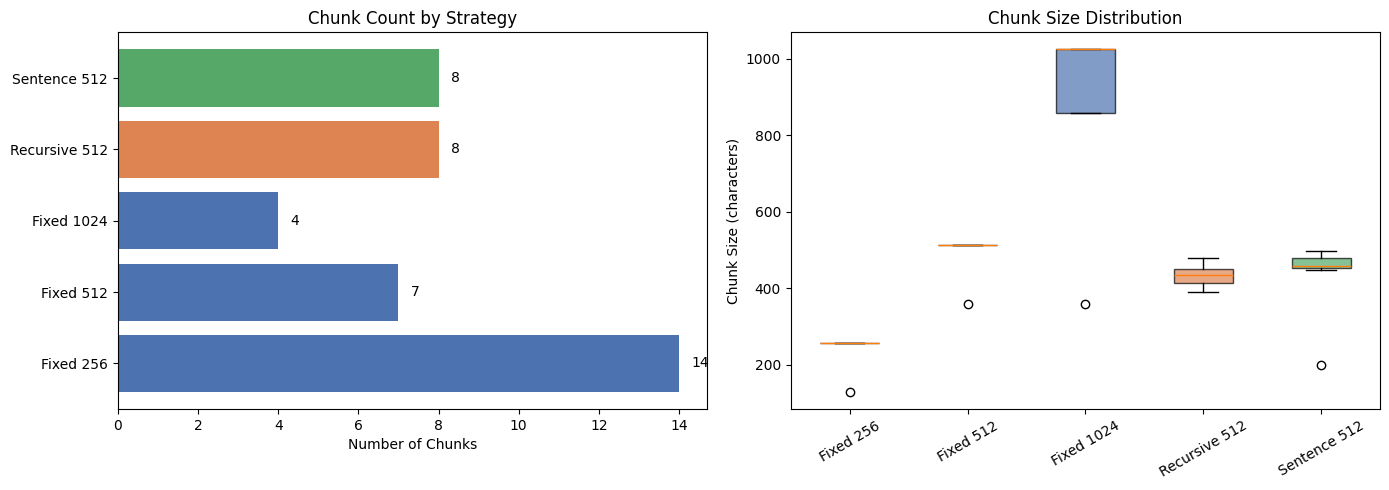

In [8]:
import matplotlib.pyplot as plt

all_strategies = {
    "Fixed 256": fixed_results["1a: size=256, overlap=25"],
    "Fixed 512": fixed_results["1b: size=512, overlap=50"],
    "Fixed 1024": fixed_results["1c: size=1024, overlap=100"],
    "Recursive 512": recursive_chunks,
    "Sentence 512": sentence_chunks,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: chunk counts
labels = list(all_strategies.keys())
counts = [len(chunks) for chunks in all_strategies.values()]
colors = ["#4C72B0", "#4C72B0", "#4C72B0", "#DD8452", "#55A868"]
axes[0].barh(labels, counts, color=colors)
axes[0].set_xlabel("Number of Chunks")
axes[0].set_title("Chunk Count by Strategy")
for i, count in enumerate(counts):
    axes[0].text(count + 0.3, i, str(count), va="center")

# Right: chunk size distributions (box plot)
size_data = [[len(c.text) for c in chunks] for chunks in all_strategies.values()]
bp = axes[1].boxplot(size_data, labels=labels, vert=True, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Chunk Size (characters)")
axes[1].set_title("Chunk Size Distribution")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 6. Overlap Verification

Verify that overlap works correctly for each strategy. For fixed chunking, the last N characters of chunk[i] should exactly equal the first N characters of chunk[i+1].

In [9]:
print("=== Fixed chunking overlap (size=512, overlap=50) ===")
chunks = fixed_results["1b: size=512, overlap=50"]
all_ok = True
for i in range(len(chunks) - 1):
    tail = chunks[i].text[-50:]
    head = chunks[i + 1].text[:50]
    match = tail == head
    if not match:
        all_ok = False
    print(f"  Chunks {i}-{i+1}: overlap match = {match}")
    print(f"    tail: {tail!r}")
    print(f"    head: {head!r}")
print(f"  All overlaps correct: {all_ok}")

print()
print("=== Using chunk_text dispatcher ===")
for strategy in ["fixed", "recursive", "sentence"]:
    result = chunk_text(text, strategy=strategy, chunk_size=512, chunk_overlap=50)
    print(f"  {strategy:>10}: {len(result)} chunks, "
          f"sizes {min(len(c.text) for c in result)}-{max(len(c.text) for c in result)}")

=== Fixed chunking overlap (size=512, overlap=50) ===
  Chunks 0-1: overlap match = True
    tail: 'nt ingestion. Raw documents — PDFs, web pages, mar'
    head: 'nt ingestion. Raw documents — PDFs, web pages, mar'
  Chunks 1-2: overlap match = True
    tail: 'with an optional overlap between consecutive chunk'
    head: 'with an optional overlap between consecutive chunk'
  Chunks 2-3: overlap match = True
    tail: 'oundaries. If a sentence is too long, it falls bac'
    head: 'oundaries. If a sentence is too long, it falls bac'
  Chunks 3-4: overlap match = True
    tail: 's grammatically complete units of meaning, which c'
    head: 's grammatically complete units of meaning, which c'
  Chunks 4-5: overlap match = True
    tail: 'l size depends on the embedding model, the retriev'
    head: 'l size depends on the embedding model, the retriev'
  Chunks 5-6: overlap match = True
    tail: ' RAG systems use recursive chunking with chunk siz'
    head: ' RAG systems use recursive chunk

## 7. Summary Table

In [10]:
import pandas as pd

rows = []
for label, chunks in all_strategies.items():
    sizes = [len(c.text) for c in chunks]
    rows.append({
        "Strategy": label,
        "Chunks": len(chunks),
        "Min Size": min(sizes),
        "Max Size": max(sizes),
        "Avg Size": round(sum(sizes) / len(sizes)),
        "Std Dev": round(pd.Series(sizes).std(), 1) if len(sizes) > 1 else 0,
        "Respects Boundaries": "No" if "Fixed" in label else "Yes",
    })

df = pd.DataFrame(rows)
df

,Strategy,Chunks,Min Size,Max Size,Avg Size,Std Dev,Respects Boundaries
0,Fixed 256,14,129,256,247,33.9,No
1,Fixed 512,7,360,512,490,57.5,No
2,Fixed 1024,4,360,1024,858,332.0,No
3,Recursive 512,8,391,480,435,30.2,Yes
4,Sentence 512,8,199,498,435,97.1,Yes


## Key Takeaways

- **Fixed chunking** produces uniform sizes but cuts through sentences and paragraphs. The overlap mechanism is exact and predictable.
- **Recursive chunking** respects document structure (paragraphs > sentences > words) at the cost of more variable chunk sizes. This is the most commonly used strategy in production RAG systems.
- **Sentence chunking** guarantees grammatically complete chunks. Sizes vary more since it packs whole sentences, but every chunk is semantically coherent.
- **Smaller chunk sizes** produce more chunks with higher retrieval precision but less context per chunk.
- **Overlap** acts as a safety net for information near boundaries, at the cost of some redundancy.

Next: Experiment 1e will add **semantic chunking** (embedding-based), which groups text by meaning rather than structural boundaries.